В цьому домашньому завданні ми проведемо додаткові експерименти для рішення задачі бінарної класифікації і створимо ваш новий submission на змагання на Kaggle.

-----------


**Завдання 0**. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle)  Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").


**Завдання 1**. **Збираємо весь код з попереднього ДЗ в одному місці.** В лекційному ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb` ми познайомились з поняттям пайплайнів, а також я показала, як компактно виглядає рішення МЛ задачі, якщо ми зберемо весь код разом.

Оскільки ми далі будемо робити експерименти, які включають ті самі етапи попередньої обробки, але інше моделювання - буде зручно мати весь код компактно і під рукою. Тому зараз ми займемось збором коду до купи :) Після цього завдання для подальших експериментів ви можете перенести частини розвʼязку взагалі в окремий `.py` файл, аби було зручно імпортувати функції.

Зі свого рішення в попередньому домашньому завданні (`Логістична регресія з scikit learn.ipynb`) зберіть усі кроки розвʼязку задачі разом з використанням `sklearn.Pipeline` за прикладом з лекції.

Ваш код нижче має містити
1. Читання даних з файлу (поза пайплайном).
2. Розбиття на тренувальний і валідаційний набори, де валідаційний містить 20% даних (поза пайплайном).
3. Виділення категоріальних і числових колонок (поза пайплайном).
4. Підготовку категоріальних і числових колонок (частина пайплайну). В прикладі в лекції ми оформлювали обробку числових і категоріальних колонок в окремі трансформери `numeric_transformer`, `categorical_cols`. Рекоемндую зробити саме так, так потім зручніше вносити зміни :)
5. Тренування лог регресії (частина пайплайну).
6. Запуск пайплайну на тренування на трен. даних (поза пайплайном).
7. Запуск пайплайну на передбачення на трен і вал. даних і вимір метрик якості ROC-AUC + вивдення Confusion Matrix (поза пайплайном).
8. Збереження моделі в формат joblib (поза пайплайном).

Ви це все вже зробили в попереднтьому ДЗ! Тож, тут просто заадча все зібрати разом.

Нижче я додала підказки, що покроково ви маєте зробити. Якщо ви почуваєтесь впевнено, можете видалити ці підказки і реалізувати все самостійно, або ж - просто заповнити пропуски.

Завдання оцінюється в 10 балів. Головний результат - аби код в фіналі був робочий. Бо за не робочий нам гроші ніхто не заплатить :)

Area under ROC score on Training dataset: 0.88


C:\Users\yevhe\AppData\Local\Temp\ipykernel_10904\3594303915.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = train_inputs.select_dtypes('object').columns.tolist()


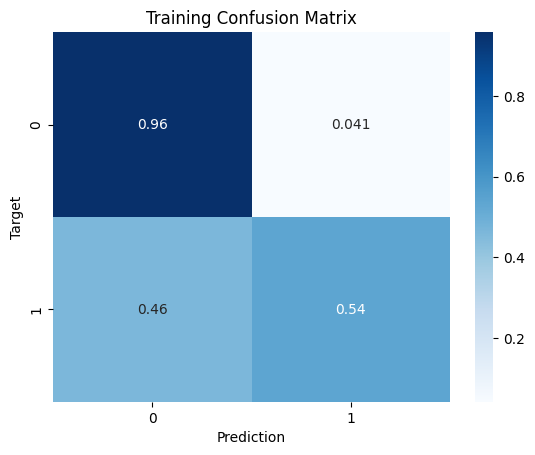

Area under ROC score on Validation dataset: 0.88


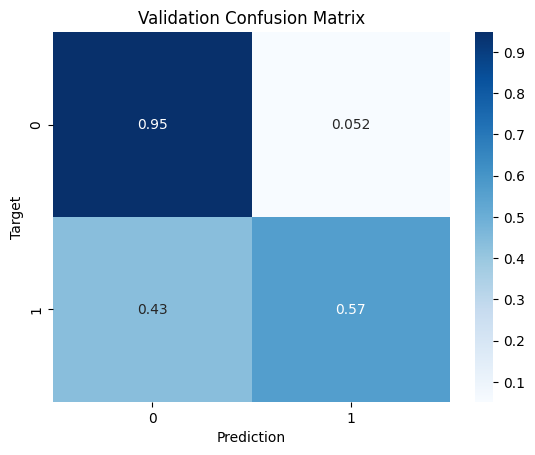

['First_pipeline.joblib']

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix


raw_df = pd.read_csv('train.csv', index_col=0)

train_df, val_df = train_test_split(raw_df, test_size=0.20, random_state=42, stratify=raw_df["Exited"]) 

# Створюємо трен. і вал. набори
input_cols = list(train_df.columns)[3:-1] 
target_col = 'Exited'
train_inputs, train_targets = train_df[input_cols].copy(), train_df[target_col].copy()
val_inputs, val_targets = val_df[input_cols].copy(), val_df[target_col].copy()

# Виявляємо числові і категоріальні колонки
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes('object').columns.tolist()

# Створюємо трансформери для числових і категоріальних колонок
numeric_transformer = Pipeline(steps=[
    ('scaler', MinMaxScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder())
])

# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Стоврюємо пайплайн, який спочатку запускає препроцесинг, потім тренуєм модель
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver="liblinear", max_iter=1000))
])

# Тренуємо пайплайн

model_pipeline.fit(train_inputs, train_targets)

# Функція, щоб передбачати і рахувати метрики
def predict_and_plot(model_pipeline, inputs, targets, name=''):
    preds = model_pipeline.predict(inputs)
    probs = model_pipeline.predict_proba(inputs)[:, 1]
    roc_auc = roc_auc_score(targets, probs)
    print(f"Area under ROC score on {name} dataset: {roc_auc:.2f}")
    confusion_matrix_ = confusion_matrix(targets, preds, normalize='true')
    plt.figure()
    sns.heatmap(confusion_matrix_, annot=True, cmap='Blues')
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))
    plt.show()
    return preds

# Оцінюємо модель на трен і вал даних
train_preds = predict_and_plot(model_pipeline, train_inputs, train_targets, 'Training')
val_preds = predict_and_plot(model_pipeline, val_inputs, val_targets, 'Validation')

# Зберігаємо модель для подальшого використання
joblib.dump(model_pipeline, 'First_pipeline.joblib')


**Завдання 2**. Такс, у нас з вами є вже готовий пайплайн. Давайте проведемо нові експерименти.

  Додайте в попередню обробку числових колонок генерацію polinomal features до степені 2 включно. Для цього створіть новий препроцесор і створіть новий пайплайн.

  Запустіть пайплайн на тренування і виведіть метрики для тренувального і валідаційного набору. Напишіть, як вам модель? Чи спостерігається в цій моделі overfit чи underfit? Чи ця модель добре генералізує?

Area under ROC score on Training dataset: 0.92


C:\Users\yevhe\AppData\Local\Temp\ipykernel_10904\3641241947.py:33: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = train_inputs.select_dtypes('object').columns.tolist()


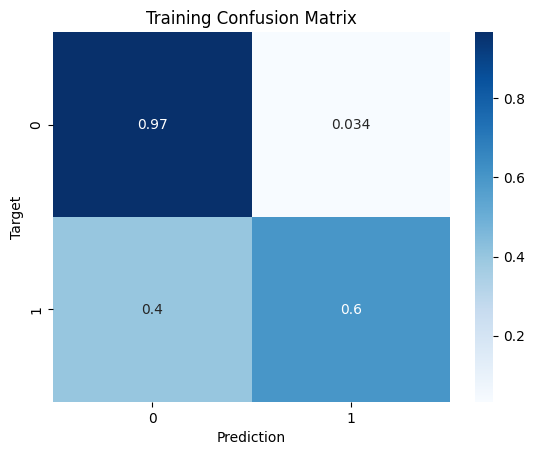

Area under ROC score on Validation dataset: 0.88


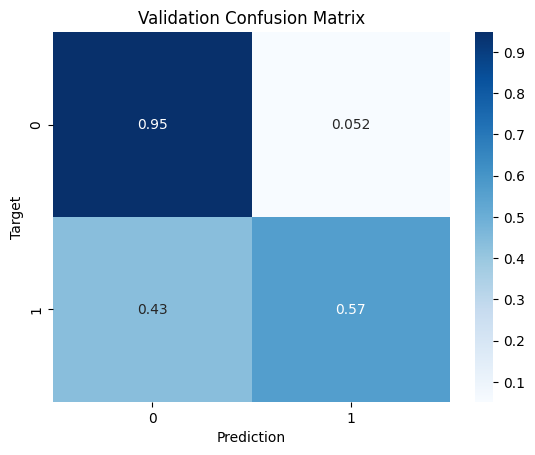

['Poly_pipeline.joblib']

In [2]:
#Я не зрозумів, чи треба повністю код копіювати, чи лише пайплайн і тд, тому беру весь код: 

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import PolynomialFeatures

from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix


raw_df = pd.read_csv('train.csv', index_col=0)

train_df, val_df = train_test_split(raw_df, test_size=0.20, random_state=42, stratify=raw_df["Exited"]) 

# Створюємо трен. і вал. набори
input_cols = list(train_df.columns)[3:-1] 
target_col = 'Exited'
train_inputs, train_targets = train_df[input_cols].copy(), train_df[target_col].copy()
val_inputs, val_targets = val_df[input_cols].copy(), val_df[target_col].copy()

# Виявляємо числові і категоріальні колонки
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes('object').columns.tolist()

# Створюємо трансформери для числових і категоріальних колонок
numeric_transformer_poly = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False))
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder())
])

# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor_poly = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_poly, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Стоврюємо пайплайн, який спочатку запускає препроцесинг, потім тренуєм модель
model_pipeline_poly = Pipeline(steps=[
    ('preprocessor', preprocessor_poly),
    ('classifier', LogisticRegression(solver="liblinear", max_iter=1000))
])

# Тренуємо пайплайн

model_pipeline_poly.fit(train_inputs, train_targets)

# Функція, щоб передбачати і рахувати метрики
def predict_and_plot(model_pipeline, inputs, targets, name=''):
    preds = model_pipeline.predict(inputs)
    probs = model_pipeline.predict_proba(inputs)[:, 1]
    roc_auc = roc_auc_score(targets, probs)
    print(f"Area under ROC score on {name} dataset: {roc_auc:.2f}")
    confusion_matrix_ = confusion_matrix(targets, preds, normalize='true')
    plt.figure()
    sns.heatmap(confusion_matrix_, annot=True, cmap='Blues')
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))
    plt.show()
    return preds

# Оцінюємо модель на трен і вал даних
train_preds_poly = predict_and_plot(model_pipeline_poly, train_inputs, train_targets, 'Training')
val_preds_poly = predict_and_plot(model_pipeline, val_inputs, val_targets, 'Validation')

# Зберігаємо модель для подальшого використання
joblib.dump(model_pipeline_poly, 'Poly_pipeline.joblib')


***ВИСНОВКИ до завдання 2: модель стала складнішою, тому почала краще презентувати тренувальні дані. ROC score для train зріс з 0.88 до 0.92. Але модель перетренована, бо ROC score покращився для тренувального набору даних, але не змінився для валідаційного. Відповідно модель не стала краще генералізувати. Нові нелінійні ознаки не допомогли покращити узагальнення.***

**Завдання 3**. Тепер давайте створимо ще новий пайплайн, тільки тепер поліноміальні ознаки згенеруємо до степені 4. Зробіть висновок про якість моделі. Якщо вам подобається резульат якоїсь з моделей в цьому ДЗ - рекомендую зробити submission в змаганні.

Area under ROC score on Training dataset: 0.93


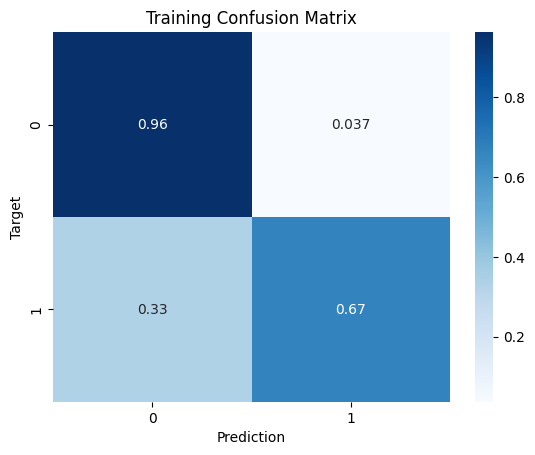

Area under ROC score on Validation dataset: 0.93


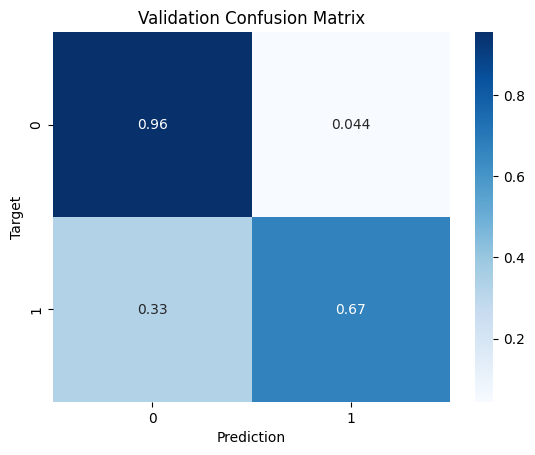

['Poly_pipeline_degree_4.joblib']

In [3]:
# Цього разу вже не копіюю весь код :)
    
numeric_transformer_poly2 = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('poly', PolynomialFeatures(degree=4, include_bias=False))
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder())
])

# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor_poly2 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_poly2, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Стоврюємо пайплайн, який спочатку запускає препроцесинг, потім тренуєм модель
model_pipeline_poly2 = Pipeline(steps=[
    ('preprocessor', preprocessor_poly2),
    ('classifier', LogisticRegression(solver="liblinear", max_iter=1000))
])

# Тренуємо пайплайн

model_pipeline_poly2.fit(train_inputs, train_targets)

# Функція, щоб передбачати і рахувати метрики
def predict_and_plot(model_pipeline, inputs, targets, name=''):
    preds = model_pipeline.predict(inputs)
    probs = model_pipeline.predict_proba(inputs)[:, 1]
    roc_auc = roc_auc_score(targets, probs)
    print(f"Area under ROC score on {name} dataset: {roc_auc:.2f}")
    confusion_matrix_ = confusion_matrix(targets, preds, normalize='true')
    plt.figure()
    sns.heatmap(confusion_matrix_, annot=True, cmap='Blues')
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))
    plt.show()
    return preds

# Оцінюємо модель на трен і вал даних
train_preds_poly2 = predict_and_plot(model_pipeline_poly2, train_inputs, train_targets, 'Training')
val_preds_poly2 = predict_and_plot(model_pipeline_poly2, val_inputs, val_targets, 'Validation')

# Зберігаємо модель для подальшого використання
joblib.dump(model_pipeline_poly2, 'Poly_pipeline_degree_4.joblib')

***ВИСНОВКИ ДО ЗАВДАННЯ 3 
Ця модель набагато краще генералізує. ROC score зріс і для тренувального, і для валідаційного наборів. Ніби немає ні недонавчання, і ні не перенавчання. Тому результат  подобається, далі завантажую на Kaggle.***

In [27]:
test_raw_df = pd.read_csv("test.csv")

In [28]:
test_raw_df.shape

(10000, 13)

In [30]:
def predict_poly2(model_pipeline, input_df: pd.DataFrame):
    prob = model_pipeline.predict_proba(input_df)[:,1]
    return prob

In [31]:
predict_poly2(model_pipeline_poly2, raw_df[:5])

array([0.09023779, 0.04919438, 0.95019147, 0.31315462, 0.99279093])

In [34]:
test_raw_df["Exited"] = predict_poly2(model_pipeline_poly2, test_raw_df)

In [37]:
sample_submission = pd.read_csv("sample_submission.csv")

In [39]:
sample_submission['Exited'] = test_raw_df['Exited']

In [40]:
sample_submission['Exited']

0       0.067415
1       0.014931
2       0.087902
3       0.402677
4       0.022045
          ...   
9995    0.009496
9996    0.011861
9997    0.009509
9998    0.112933
9999    0.090301
Name: Exited, Length: 10000, dtype: float64

In [41]:
sample_submission.to_csv("submission_log_reg.csv", index=False)

**Завдання 4. Перенавчання і регуляризація**.

  Скачайте набір даних `regression_data.csv`. Звичайте набір даних з `regression_data.csv`, розбийте на train і test (в тест 20%) і натренуйте модель лінійної регресії з масштабуванням числових ознак і поліноміальними ознаками до степені **5 включно**.

  Виміряйте якість прогностичної моделі і зробіть висновок, чи модель хороша, чи вона добре генералізує?


In [53]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

In [47]:
raw_df_2 = pd.read_csv('regression_data.csv')
raw_df_2.head(5)

,feature_1,feature_2,feature_3,feature_4,feature_5,target
0,-0.190339,-1.382800,-0.875618,0.538910,-1.037246,28.938854
1,-0.321386,-0.563725,0.412931,-0.147057,-0.825497,-7.664581
2,2.122156,-1.519370,1.032465,-1.260884,0.917862,-63.845482
3,-1.380101,-0.055548,-1.703382,0.074095,1.628616,4.076259
4,-0.072829,-1.514847,-0.846794,0.714000,0.473238,34.879013


In [48]:
train_df_2, val_df_2 = train_test_split(raw_df_2, test_size=0.20, random_state=42) 

In [49]:
input_cols_2 = list(train_df_2.columns)[:-1] 
target_col_2 = 'target'
train_inputs_2, train_targets_2 = train_df_2[input_cols_2].copy(), train_df_2[target_col_2].copy()
val_inputs_2, val_targets_2 = val_df_2[input_cols_2].copy(), val_df_2[target_col_2].copy()

In [58]:
numeric_transformer_reg = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('poly', PolynomialFeatures(degree=5, include_bias=False))
])

preprocessor_reg = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_reg, input_cols_2)
    ])

model_pipeline_reg = Pipeline(steps=[
    ('preprocessor', preprocessor_reg),
    ('regressor', LinearRegression())
])


model_pipeline_reg.fit(train_inputs_2, train_targets_2)

# Функція, щоб передбачати і рахувати метрики
def predict_and_evaluate(model_pipeline, inputs, targets, name=''):
    preds = model_pipeline.predict(inputs)
    r2 = r2_score(targets, preds)
    rmse = np.sqrt(mean_squared_error(targets, preds))
    mae = mean_absolute_error(targets, preds)

    print(f"{name} R2: {r2:.4f}")
    print(f"{name} RMSE: {rmse:.4f}")
    print(f"{name} MAE: {mae:.4f}")
    return preds

# Оцінюємо модель на трен і вал даних
train_preds_reg = predict_and_evaluate(model_pipeline_reg, train_inputs_2, train_targets_2, 'Training')
val_preds_reg = predict_and_evaluate(model_pipeline_reg, val_inputs_2, val_targets_2, 'Validation')

# Зберігаємо модель для подальшого використання
joblib.dump(model_pipeline_reg, 'Regression_degree_5.joblib')

Training R2: 1.0000
Training RMSE: 0.0000
Training MAE: 0.0000
Validation R2: 0.8710
Validation RMSE: 17.3488
Validation MAE: 10.8340


['Regression_degree_5.joblib']

***ВИСНОВКИ ДО ЗАВДАННЯ 4: Модель неякісна, бо перенавчена. Для тренувального набору R2 аж 1, а відхилень немає. Водночас R2=0.87 для валідаційного набору даних.Тобто модель погано генералізує, бо перенавчена. Зокрема можливо вона надто складна, бо ми беремо поліноміальні ознаки до степені 5.***  

**Завдання 5**. Натренуйте моделі Lasso(), Ridge(), ElasaticNet() на цих даних (з поліном ознаками до степені 20 включно), порівняйте якість з тою, яка була отримана з лінійною регресією. Яка модель найкраще генералізує і чому на ваш погляд (можливо треба буде для відповіді зробити додатковий аналіз ознак)?

In [70]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import root_mean_squared_error

In [71]:
#Використав попередній код+приклади з лекції

#перелік моделей для функції
models = [
    LinearRegression(),
    Ridge(),
    Lasso(),
    ElasticNet()
]

#оновий пайплайн
numeric_transformer_reg2 = Pipeline(steps=[
      ('poly', PolynomialFeatures(degree=20, include_bias=False)),
      ('scaler', MinMaxScaler())
])

preprocessor_reg2 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_reg2, input_cols_2)
    ])


#функція, щоб передбачити і оцінити
def evaluate_model(model, X_train, y_train, X_val, y_val):
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)

    train_metrics = round(root_mean_squared_error(y_train, y_train_pred), 6)
    val_metrics = round(root_mean_squared_error(y_val, y_val_pred), 6)

    return dict(train=train_metrics, val=val_metrics)


In [72]:
#запускаю цикл для перевірки метрик 
for model in models:
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor_reg2),
        ('regressor', model)
    ])
    
    pipeline.fit(train_inputs_2, train_targets_2)
    eval_results = evaluate_model(
        pipeline,
        train_inputs_2, train_targets_2,
        val_inputs_2, val_targets_2
    )
    print(f'{str(model)}: {eval_results}\n')

LinearRegression(): {'train': 0.0, 'val': 15.674311}

Ridge(): {'train': 8.59775, 'val': 76.562708}

Lasso(): {'train': 5.098171, 'val': 5.671931}

ElasticNet(): {'train': 34.179765, 'val': 116.029707}



In [76]:
lasso_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_reg2),
    ('regressor', Lasso())
])

lasso_pipeline.fit(train_inputs_2, train_targets_2)

lasso_coefs = lasso_pipeline.named_steps['regressor'].coef_
lasso_coefs

array([-0., -0., -0., ..., -0., -0., -0.], shape=(53129,))

In [80]:
num_zero = np.sum(lasso_coefs == 0)
num_total = len(lasso_coefs)

print("Кількість занулених кофів:", num_zero)
print("Не занулені кофи:", num_total - num_zero)

Кількість занулених кофів: 53128
Не занулені кофи: 1


***ВИСНОВКИ:***
- По лінійній регреції бачимо те саме - RMSE=0 для тренувального набору, що підтверджує те, що модель перенавчена. При цьому для валідаційного набору показник майже 16.
- Найкращий результат має Лассо. Результат для тренувального та валідаційного наборів дуже близькі. При цьому відхилення фактично найнижчі для валідаційного набору. Тобто модель добре генералізує.
- По інших моделях дуже великий розрив між помилкою для тренувального та валідації. Моделі недонавчені мабуть, або вплив сильної регуляризації.
- Пошукав як перевірити Лассо. Модель занулила більшість коефіцієнтів, залишивши тільки 1. 